# Computer Vision Project 1: Image Filtering and Hybrid Images

All projects in this course will be executed within an iPython notebook. Using an IPython notebooks is a convenient way for you to quickly and easily interact with the code. A notebook contains many blocks of code, each of which can be run independently. You can run a cell with ctrl+enter or shift+enter (to move to the next cell).


## Part 1: NumPy
### Setup
Before we get started, we'll do a quick check to ensure you've previously installed the `proj1_code` module by running the command `pip install -e .` in your terminal:

In [2]:
from proj1_code.utils import load_image, save_image

If that didn't throw an error, then you're good to proceed!

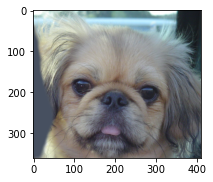

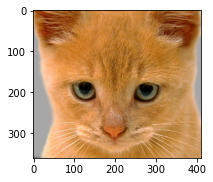

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from proj1_code.utils import load_image, save_image

%matplotlib inline
%load_ext autoreload
%autoreload 2


image1 = load_image('../data/1a_dog.bmp')
image2 = load_image('../data/1b_cat.bmp')

# display the dog and cat images
plt.figure(figsize=(3,3)); plt.imshow((image1*255).astype(np.uint8));
plt.figure(figsize=(3,3)); plt.imshow((image2*255).astype(np.uint8));

### Create filter

You will first need to implement `create_Gaussian_kernel_1D()`  in `part1.py`.

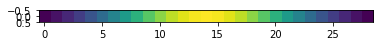

In [4]:
from proj1_code.part1 import create_Gaussian_kernel_1D
ksize = 29
sigma = 7
kernel_1d = create_Gaussian_kernel_1D(ksize, sigma)
plt.imshow(kernel_1d.T) # plot (N,1) column vector as (1,N) row vector 

You can run these two simple test cases to check if the implementation seems correct:

In [5]:
from proj1_code.utils import verify
from proj1_unit_tests.test_part1 import (
    test_create_Gaussian_kernel_1D,
    test_create_Gaussian_kernel_1D_sumsto1,
    test_create_Gaussian_kernel_1D_peak
)

print(verify(test_create_Gaussian_kernel_1D))
print(verify(test_create_Gaussian_kernel_1D_sumsto1))
print(verify(test_create_Gaussian_kernel_1D_peak))

"Correct"
"Correct"
"Correct"


Next, you will need to implement `create_Gaussian_kernel_2D()` (which can use `create_Gaussian_kernel_1D`)  in `part1.py`.

"Correct"
"Correct"
"Correct"
"Correct"
"Correct"


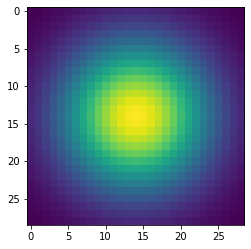

In [6]:
from proj1_code.part1 import create_Gaussian_kernel_2D
from proj1_code.utils import verify, PIL_resize
from proj1_unit_tests.test_part1 import (
    test_create_Gaussian_kernel_2D_sumsto1,
    test_create_Gaussian_kernel_2D_peak,
    test_gaussian_kernel_2D
)

cutoff_frequency = 7
kernel = create_Gaussian_kernel_2D(cutoff_frequency)

# let's take a look at the filter!
plt.figure(figsize=(4,4)); plt.imshow(kernel);

## Verify that the Gaussian kernel was created correctly
print(verify(test_create_Gaussian_kernel_1D_sumsto1))
print(verify(test_create_Gaussian_kernel_1D_peak))
print(verify(test_create_Gaussian_kernel_2D_sumsto1))
print(verify(test_create_Gaussian_kernel_2D_peak))
print(verify(test_gaussian_kernel_2D))

### Apply filter to image
The next two functions you need to implement in this project can also be found in `part1.py`. Start by implementing `my_conv2d_numpy`, which takes both a filter and an image, and returns the filtered image. This code block will use your `my_conv2d_numpy` function to create and display a blurry version of image1.

"Correct"
"Correct"
"Correct"


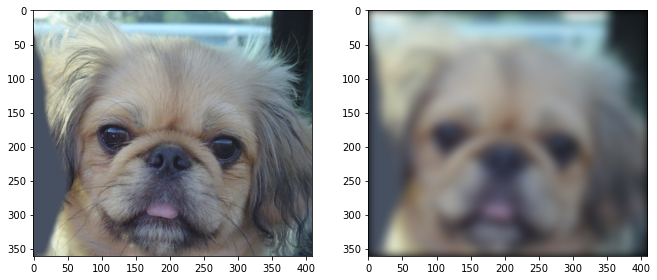

In [7]:
from proj1_code.part1 import (
    my_conv2d_numpy,
    create_hybrid_image
)
from proj1_unit_tests.test_part1 import (
    test_my_conv2d_numpy_identity,
    test_my_conv2d_numpy_ones_filter,
    test_my_conv2d_numpy_nonsquare_filter
)

blurry_image = my_conv2d_numpy(image1, kernel)

plt.figure(figsize=(11,6))
plt.subplot(1,2,1); plt.imshow(image1)
plt.subplot(1,2,2); plt.imshow((blurry_image*255).astype(np.uint8))

## Verify that my_conv2d_numpy() was implemented correctly
print(verify(test_my_conv2d_numpy_identity))
print(verify(test_my_conv2d_numpy_ones_filter))
print(verify(test_my_conv2d_numpy_nonsquare_filter))

## Test Filtering

Here are a few test cases to help you test `my_conv2d_numpy()`, which you will write. You should verify that you get reasonable output here before using your filtering to construct a hybrid image in `part1.py`. The outputs are all saved and you can include them in your writeup.

In [8]:
test_image = load_image('../data/1b_cat.bmp')
original_height = test_image.shape[0]
original_width = test_image.shape[1]
test_image = PIL_resize(test_image, (int(0.7*original_width), int(0.7*original_height)))

### Identity filter
For the identity filter, the filtering result should look identical to the input.

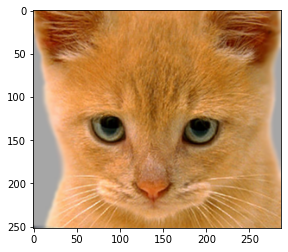

In [9]:
identity_filter = np.asarray([[0, 0, 0], [0, 1, 0], [0, 0, 0]])
identity_image = my_conv2d_numpy(test_image, identity_filter)
plt.imshow(identity_image)
done = save_image('../results/part1/identity_image.jpg', identity_image)

### Small blur with a box filter
This filter should remove some high frequencies. (See the effect on the cat's whiskers, for example.)

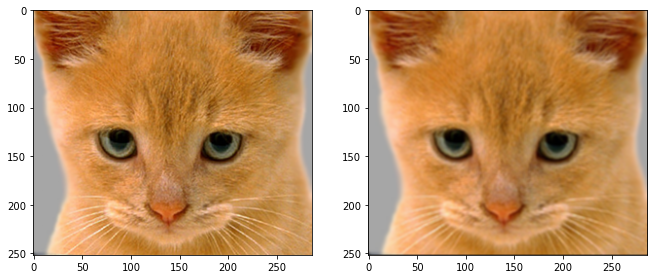

In [10]:
blur_filter = np.ones((3,3)) 
blur_filter /= np.sum(blur_filter)  # making the filter sum to 1
blur_image = my_conv2d_numpy(test_image, blur_filter)
plt.figure(figsize=(11,6))
plt.subplot(1,2,1); plt.imshow(test_image)
plt.subplot(1,2,2); plt.imshow(blur_image)
done = save_image('../results/part1/blur_image.jpg', blur_image)

### Optimized my_conv2d_numpy()
Previous implementation of `my_conv2d_numpy()` remains a significant issue: the filtered image exhibit black borders around the edges, which become increasingly noticeable as the kernel size grows. Lets try to mitigate this issue.

Hint: You may consider the implementation of padding process. We encourage discussing various implementations in the report.

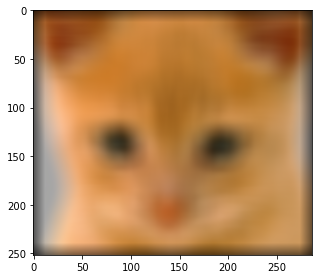

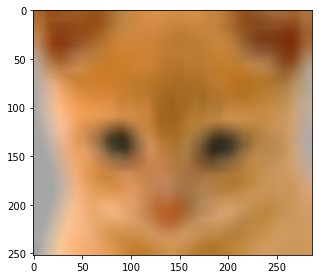

In [11]:
large_blur_filter = np.ones((25, 25))
large_blur_filter /= np.sum(large_blur_filter)
large_blur_image = my_conv2d_numpy(test_image, large_blur_filter)
plt.figure(figsize=(11,6)); plt.subplot(1,2,1); plt.imshow(large_blur_image); plt.show()    # you may see obvious black borders around the image edge
done = save_image("../results/part1/large_blur_image.jpg", large_blur_image)
# Here, you need to implement a v2 to optimize the issue mentioned above (1.4):
from proj1_code.part1 import (
    my_conv2d_numpy_v2,
)
large_blur_image = my_conv2d_numpy_v2(test_image, large_blur_filter)
plt.figure(figsize=(11,6)); plt.subplot(1,2,1); plt.imshow(large_blur_image); plt.show()
done = save_image("../results/part1/large_blur_image_v2.jpg", large_blur_image)

### Oriented filter (Sobel operator)

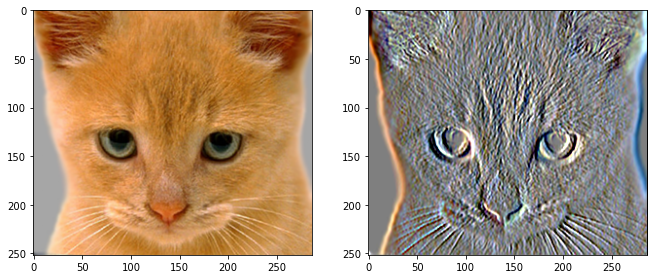

In [12]:
sobel_filter = np.asarray([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])  # should respond to horizontal gradients
sobel_image = my_conv2d_numpy(test_image, sobel_filter)

# 0.5 added because the output image is centered around zero otherwise and mostly black
sobel_image = np.clip(sobel_image+0.5, 0.0, 1.0)
plt.figure(figsize=(11,6))
plt.subplot(1,2,1); plt.imshow(test_image)
plt.subplot(1,2,2); plt.imshow(sobel_image)
done = save_image('../results/part1/sobel_image.jpg', sobel_image)

### High pass filter (discrete Laplacian)

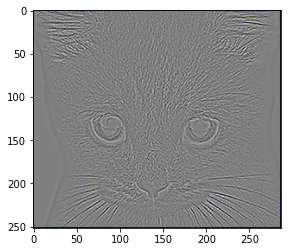

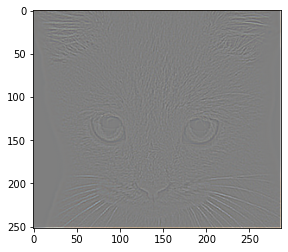

In [13]:
laplacian_filter = np.asarray([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
laplacian_image = my_conv2d_numpy(test_image, laplacian_filter)

# 0.5 is added because the output image is centered around zero otherwise and mostly black
laplacian_image = np.clip(laplacian_image+0.5, 0.0, 1.0)
plt.figure(); plt.imshow(laplacian_image)
done = save_image('../results/part1/laplacian_image.jpg', laplacian_image)

# High pass "filter" alternative
high_pass_image = test_image - blur_image
high_pass_image = np.clip(high_pass_image+0.5, 0.0, 1.0)
plt.figure(); plt.imshow(high_pass_image)
done = save_image('../results/part1/high_pass_image.jpg', high_pass_image)

## Create hybrid image
Next, implement `create_hybrid_image()`, which takes two images and makes a hybrid image using the low frequency content from one image and the high frequency content from another by applying the Gaussian kernel you defined in `create_Gaussian_kernel_2D()`.

Experiment with the value of `cutoff_frequency` for each pair of images in `data/`. For each image pair, replace `cutoff_frequencies.txt` with the best cutoff frequency value you find. The value on line *i* of the text file should correspond to _i_-th image pair. This is an important step for Part 2! Feel free to also experiment with which image in each pair you grab the low frequencies from and which image you grab high frequencies from.

In [14]:
from proj1_code.utils import vis_image_scales_numpy
from proj1_unit_tests.test_part1 import test_hybrid_image_np

low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, kernel)

## Verify that results are as expected
print(verify(test_hybrid_image_np))

vis = vis_image_scales_numpy(hybrid_image)

"Correct"


### Show results

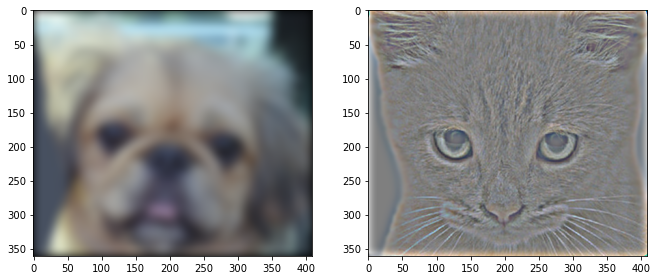

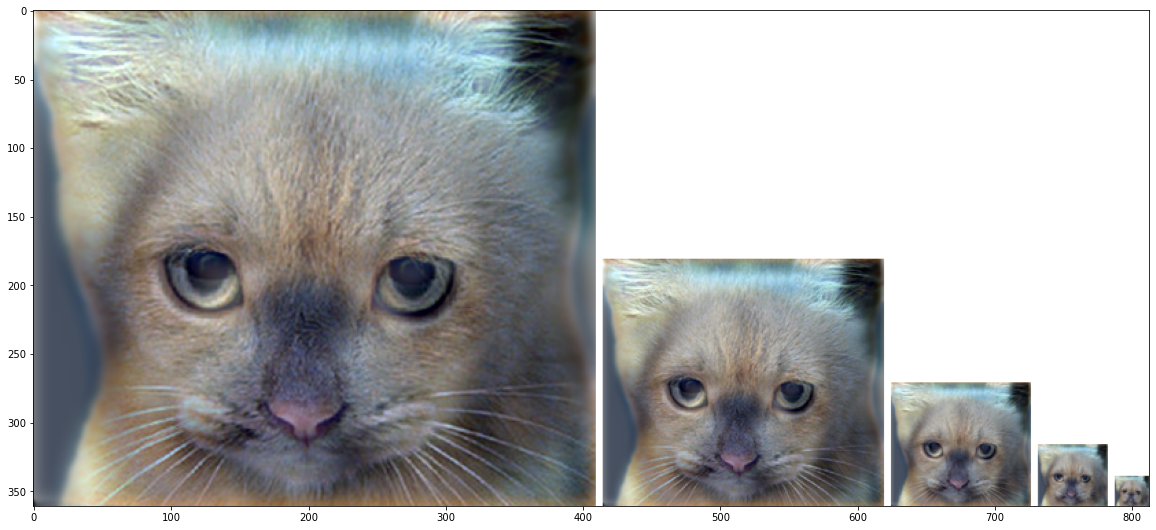

In [15]:
plt.figure(figsize=(11,6));
plt.subplot(1,2,1); plt.imshow((low_frequencies*255).astype(np.uint8));
plt.subplot(1,2,2); plt.imshow(((high_frequencies+0.5)*255).astype(np.uint8));
plt.figure(figsize=(20, 20)); plt.imshow(vis);

### Save results

In [16]:
save_image('../results/part1/low_frequencies.jpg', low_frequencies)
save_image('../results/part1/high_frequencies.jpg', high_frequencies+0.5)
save_image('../results/part1/hybrid_image.jpg', hybrid_image)
save_image('../results/part1/hybrid_image_scales.jpg', vis)

### Custom Hybrid Image
You are required to find at least one such pair of images from daily life or the internet to create your own custom hybrid image. In your report, please analyze what factors you believe contribute to the differences in the results produced by various image pairs.

In [ ]:
raise NotImplementedError(
    "You need to find a image pair, and create the corresponding hybrid image."
)

处理图像对: 猫+狗


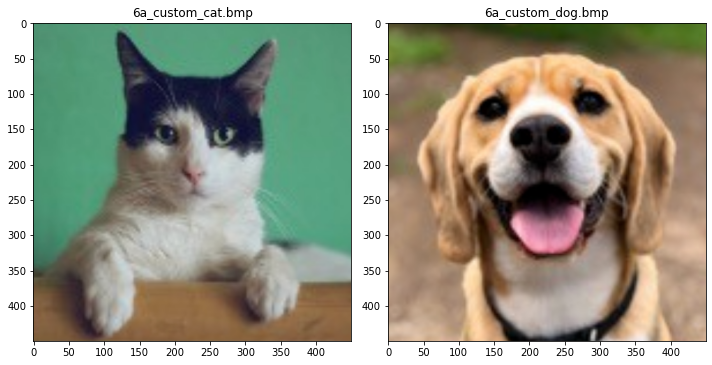

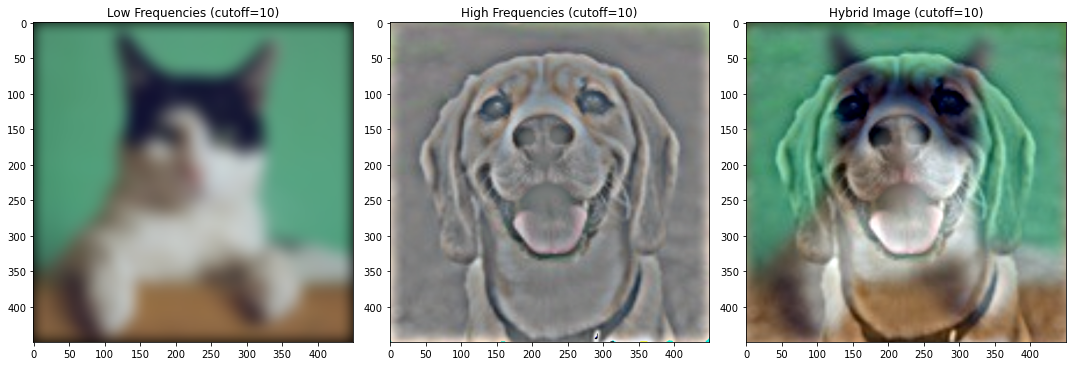

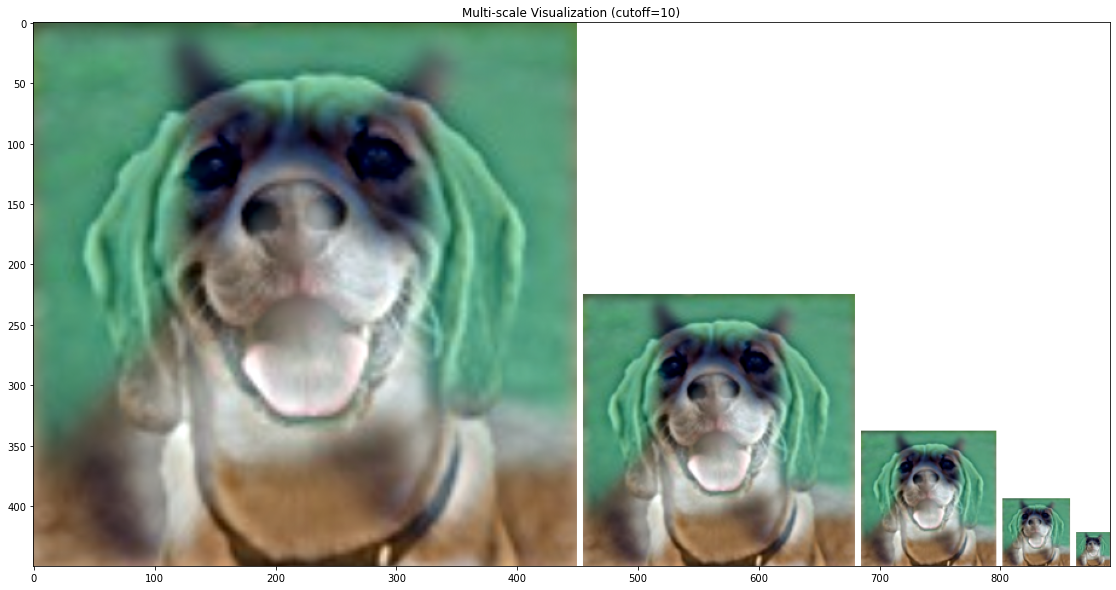

图像对 猫+狗 的截止频率: 10
---------------------------------------------------
cutoff_frequencies.txt file has been updated
All hybrid images have been generated with the following cutoff frequencies:
Motorcycle + Bicycle: 10


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from proj1_code.utils import load_image, save_image, vis_image_scales_numpy
from proj1_code.part1 import create_Gaussian_kernel_2D, create_hybrid_image
import os

if not os.path.exists('../results/part1_custom/'):
    os.makedirs('../results/part1_custom/')

def create_custom_hybrid():
    print("处理图像对: 猫+狗")
    
    # 加载图像
    image1 = load_image("../data/6a_custom_cat.bmp")
    image2 = load_image("../data/6a_custom_dog.bmp")
    
    # 显示原始图像
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow((image1*255).astype(np.uint8))
    plt.title("6a_custom_cat.bmp")
    plt.subplot(1, 2, 2)
    plt.imshow((image2*255).astype(np.uint8))
    plt.title("6a_custom_dog.bmp")
    plt.tight_layout()
    plt.show()
    
    cutoff_frequency = 10
    kernel = create_Gaussian_kernel_2D(cutoff_frequency)
    low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, kernel)
    
    # 显示结果
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow((low_frequencies*255).astype(np.uint8))
    plt.title(f"Low Frequencies (cutoff={cutoff_frequency})")
    
    plt.subplot(1, 3, 2)
    plt.imshow(((high_frequencies+0.5)*255).astype(np.uint8))
    plt.title(f"High Frequencies (cutoff={cutoff_frequency})")
    
    plt.subplot(1, 3, 3)
    plt.imshow((hybrid_image*255).astype(np.uint8))
    plt.title(f"Hybrid Image (cutoff={cutoff_frequency})")
    plt.tight_layout()
    plt.show()
    
    # 显示多尺度效果
    vis = vis_image_scales_numpy(hybrid_image)
    plt.figure(figsize=(20, 10))
    plt.imshow(vis)
    plt.title(f"Multi-scale Visualization (cutoff={cutoff_frequency})")
    plt.show()
    
    # 保存结果
    save_image('../results/part1_custom/5_low_frequencies.jpg', low_frequencies)
    save_image('../results/part1_custom/5_high_frequencies.jpg', high_frequencies+0.5)
    save_image('../results/part1_custom/5_hybrid_image.jpg', hybrid_image)
    save_image('../results/part1_custom/5_hybrid_image_scales.jpg', vis)
    
    print(f"图像对 猫+狗 的截止频率: {cutoff_frequency}")
    print("---------------------------------------------------")
    
    return cutoff_frequency

def update_cutoff_frequencies():
    cutoffs = [
        7,  # Dog + Cat
        4,  # Motorcycle + Bicycle
        8,  # Plane + Bird
        5, # Einstein + Marilyn
        4,  # Submarine + Fish
        10 # 自定义
    ]
    
    with open('../cutoff_frequencies.txt', 'w') as f:
        for cutoff in cutoffs:
            f.write(f"{cutoff}\n")
    print("cutoff_frequencies.txt file has been updated")

def main():
    custom_cutoff = create_custom_hybrid()

    update_cutoff_frequencies()
    
    print("All hybrid images have been generated with the following cutoff frequencies:")
    print("Motorcycle + Bicycle:", custom_cutoff)

if __name__ == "__main__":
    main()

## Part 2: PyTorch 

Make sure you have specified a cutoff value in `cutoff_frequencies.txt` for each image pair in `data/` before executing the following blocks.

In [35]:
import torch
import torchvision
import os

from proj1_code.part2_datasets import HybridImageDataset
from proj1_code.part2_models import HybridImageModel

if not os.path.exists('../results/part2/'):
        os.makedirs('../results/part2/')
        
data_root = '../data' # if you're using additional data, make sure to change this to '../additional_data'
cf_file = '../cutoff_frequencies.txt'

### Instantiate model & dataset
Implement `HybridImageModel` and `HybridImageDataset`, found in `part2_models.py` and `part2_datasets.py`, respectively.

In the code documentation, you will see a term called "batch size", which we will discuss in later projects and lectures. For now, we are using the default value of 1. 

In [36]:
import importlib
import proj1_code.part2_datasets
import proj1_code.part2_models
importlib.reload(proj1_code.part2_datasets)
importlib.reload(proj1_code.part2_models)

model = HybridImageModel()
dataset = HybridImageDataset(data_root, cf_file)
dataloader = torch.utils.data.DataLoader(dataset)

data_iter = iter(dataloader)

目录 ../data 中的文件列表:
  - 1a_dog.bmp
  - 1b_cat.bmp
  - 2a_motorcycle.bmp
  - 2b_bicycle.bmp
  - 3a_plane.bmp
  - 3b_bird.bmp
  - 4a_einstein.bmp
  - 4b_marilyn.bmp
  - 5a_submarine.bmp
  - 5b_fish.bmp
  - 6a_custom_cat.bmp
  - 6a_custom_dog.bmp
找到 6 张A组图像和 6 张B组图像
A组第一张图像: ../data\1a_dog.bmp
B组第一张图像: ../data\1b_cat.bmp


### Create hybrid images
This code block will iterate through pairs of images from your dataset and create a hybrid image using the low frequency content from one image and the high frequency content from another.

In [37]:
for i in range(len(dataset)):
    image_a, image_b, cutoff_frequency = next(data_iter)
    low_frequencies, high_frequencies, hybrid_image = model(image_a, image_b, cutoff_frequency)
    
    # saves low frequencies, high frequencies, and hybrid image of each pair of images
    torchvision.utils.save_image(low_frequencies, '../results/part2/%d_low_frequencies.jpg' % i)
    torchvision.utils.save_image(high_frequencies+0.5, '../results/part2/%d_high_frequencies.jpg' % i)
    torchvision.utils.save_image(hybrid_image, '../results/part2/%d_hybrid_image.jpg' % i)

In [38]:
## Verify that the results are correct
from proj1_unit_tests.test_part2 import (
    test_low_freq_sq_kernel_pytorch, 
    test_high_freq_sq_kernel_pytorch,
    test_hybrid_image_pytorch
)

## Verify that the Pytorch results are as expected
print(verify(test_low_freq_sq_kernel_pytorch))
print(verify(test_high_freq_sq_kernel_pytorch))
## Verify that the Pytorch hybrid images are created correctly
print(verify(test_hybrid_image_pytorch))

目录 E:\Codes\2025.2_CV\proj1\proj1_code/data 中的文件列表:
  - 1a_dog.bmp
  - 1b_cat.bmp
  - 2a_motorcycle.bmp
  - 2b_bicycle.bmp
  - 3a_plane.bmp
  - 3b_bird.bmp
  - 4a_einstein.bmp
  - 4b_marilyn.bmp
  - 5a_submarine.bmp
  - 5b_fish.bmp
  - 6a_custom_cat.bmp
  - 6a_custom_dog.bmp
找到 6 张A组图像和 6 张B组图像
A组第一张图像: E:\Codes\2025.2_CV\proj1\proj1_code/data\1a_dog.bmp
B组第一张图像: E:\Codes\2025.2_CV\proj1\proj1_code/data\1b_cat.bmp
"Correct"
目录 E:\Codes\2025.2_CV\proj1\proj1_code/data 中的文件列表:
  - 1a_dog.bmp
  - 1b_cat.bmp
  - 2a_motorcycle.bmp
  - 2b_bicycle.bmp
  - 3a_plane.bmp
  - 3b_bird.bmp
  - 4a_einstein.bmp
  - 4b_marilyn.bmp
  - 5a_submarine.bmp
  - 5b_fish.bmp
  - 6a_custom_cat.bmp
  - 6a_custom_dog.bmp
找到 6 张A组图像和 6 张B组图像
A组第一张图像: E:\Codes\2025.2_CV\proj1\proj1_code/data\1a_dog.bmp
B组第一张图像: E:\Codes\2025.2_CV\proj1\proj1_code/data\1b_cat.bmp
"Correct"
目录 E:\Codes\2025.2_CV\proj1\proj1_code/data 中的文件列表:
  - 1a_dog.bmp
  - 1b_cat.bmp
  - 2a_motorcycle.bmp
  - 2b_bicycle.bmp
  - 3a_plane.bmp
  - 

### Hybrid image timing comparison
Here, we will compare the runtime of creating hybrid images using your NumPy implementation to using your PyTorch implementation.

In [39]:
import time

image1 = load_image('../data/1a_dog.bmp')
image2 = load_image('../data/1b_cat.bmp')

Timing Part 1. Notice that we explicitly include `create_Gaussian_kernel()_2D` in the timing of Part 1 but not Part 2. This is because the function is already being called (and therefore timed) inside the forward pass of `HybridImageModel`.

In [40]:
start = time.time()
cutoff_frequency = 7
kernel = create_Gaussian_kernel_2D(cutoff_frequency)
low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, kernel)
end = time.time() - start
print('Part 1: {:.3f} seconds'.format(end))

Part 1: 3.528 seconds


Timing Part 2

In [41]:
model = HybridImageModel()

start = time.time()
low_frequencies, high_frequencies, hybrid_image = model(image_a, image_b, torch.Tensor([cutoff_frequency]))
end = time.time() - start
print('Part 2: {:.3f} seconds'.format(end))

Part 2: 1.037 seconds


处理图像对: 狗+猫
处理时间: 0.769 秒


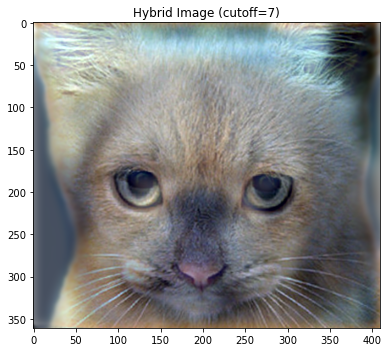

图像对 狗+猫 的截止频率: 7
---------------------------------------------------
处理图像对: 摩托车+自行车
处理时间: 0.255 秒


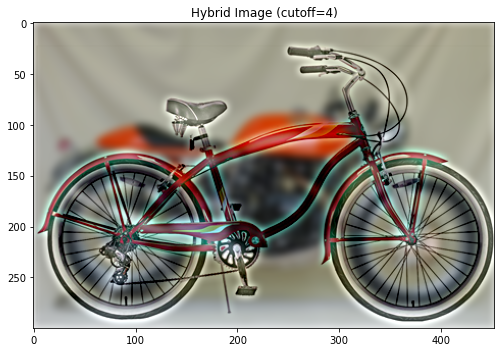

图像对 摩托车+自行车 的截止频率: 4
---------------------------------------------------
处理图像对: 飞机+鸟
处理时间: 0.867 秒


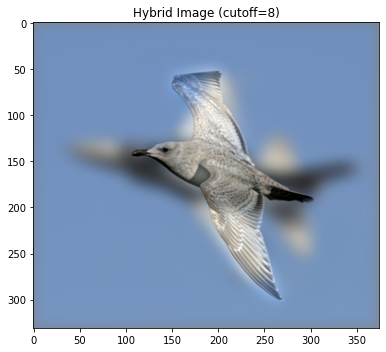

图像对 飞机+鸟 的截止频率: 8
---------------------------------------------------
处理图像对: 爱因斯坦+玛丽莲
处理时间: 0.165 秒


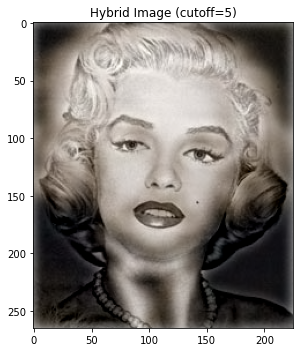

图像对 爱因斯坦+玛丽莲 的截止频率: 5
---------------------------------------------------
处理图像对: 潜艇+鱼
处理时间: 0.213 秒


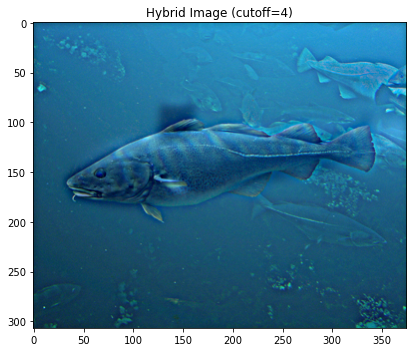

图像对 潜艇+鱼 的截止频率: 4
---------------------------------------------------
处理图像对: 自定义猫+狗
处理时间: 2.421 秒


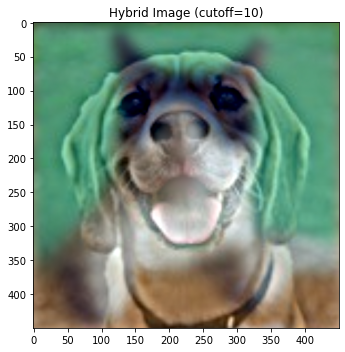

图像对 自定义猫+狗 的截止频率: 10
---------------------------------------------------
已更新 cutoff_frequencies.txt 文件
已生成所有混合图像，使用以下截止频率:
狗+猫: 7
摩托车+自行车: 4
飞机+鸟: 8
爱因斯坦+玛丽莲: 5
潜艇+鱼: 4
自定义猫+狗: 10

比较 Part 1 和 Part 2 的运行时间:
Part 1 (NumPy 实现): 3.584 秒
Part 2 (PyTorch 实现): 0.746 秒
加速比: 4.81倍
PyTorch 实现比 NumPy 实现快了 380.55%


In [45]:
# 这里我们将实现使用 PyTorch 创建自定义混合图像的代码
# 使用单独的函数处理每对图像，并手动指定截止频率

# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import os
import time
from PIL import Image
from torchvision import transforms
from proj1_code.utils import save_image
from proj1_code.part2_models import HybridImageModel

# 确保结果目录存在
if not os.path.exists('../results/part2_custom/'):
    os.makedirs('../results/part2_custom/')

def process_image_pair(image1_path, image2_path, cutoff_frequency, pair_name, index):
    """
    处理一对图像并创建混合图像
    
    Args:
        image1_path: 第一张图像的路径
        image2_path: 第二张图像的路径
        cutoff_frequency: 截止频率
        pair_name: 图像对的名称
        index: 图像对的索引
    """
    print(f"处理图像对: {pair_name}")
    
    # 加载图像并转换为 PyTorch 张量
    transform = transforms.ToTensor()
    
    # 打开并转换图像
    image1_pil = Image.open(image1_path)
    image2_pil = Image.open(image2_path)
    
    image1 = transform(image1_pil)
    image2 = transform(image2_pil)
    
    # 增加批次维度
    image1 = image1.unsqueeze(0)
    image2 = image2.unsqueeze(0)
    
    # 创建模型
    model = HybridImageModel()
    
    # 测量处理时间
    start = time.time()
    
    # 使用 PyTorch 模型生成混合图像
    low_frequencies, high_frequencies, hybrid_image = model(image1, image2, torch.Tensor([cutoff_frequency]))
    
    end = time.time() - start
    print(f'处理时间: {end:.3f} 秒')
    
    # 转换为 NumPy 数组进行显示
    low_freq_np = low_frequencies[0].permute(1, 2, 0).numpy()
    high_freq_np = high_frequencies[0].permute(1, 2, 0).numpy()
    hybrid_np = hybrid_image[0].permute(1, 2, 0).numpy()
    
    # 显示结果
    plt.figure(figsize=(15, 5))
    plt.imshow(hybrid_np)
    plt.title(f"Hybrid Image (cutoff={cutoff_frequency})")
    plt.tight_layout()
    plt.show()

    # 保存结果
    torchvision.utils.save_image(hybrid_image, f'../results/part2_custom/{index}_{pair_name}_hybrid_image.jpg')
    
    print(f"图像对 {pair_name} 的截止频率: {cutoff_frequency}")
    print("---------------------------------------------------")
    
    return cutoff_frequency

def process_all_pairs():
    # 定义图像对和截止频率
    image_pairs = [
        ("../data/1a_dog.bmp", "../data/1b_cat.bmp", 7, "狗+猫", 1),
        ("../data/2a_motorcycle.bmp", "../data/2b_bicycle.bmp", 4, "摩托车+自行车", 2),
        ("../data/3a_plane.bmp", "../data/3b_bird.bmp", 8, "飞机+鸟", 3),
        ("../data/4a_einstein.bmp", "../data/4b_marilyn.bmp", 5, "爱因斯坦+玛丽莲", 4),
        ("../data/5a_submarine.bmp", "../data/5b_fish.bmp", 4, "潜艇+鱼", 5),
        ("../data/6a_custom_cat.bmp", "../data/6a_custom_dog.bmp", 10, "自定义猫+狗", 6)
    ]
    
    cutoff_frequencies = []
    pair_names = []
    
    # 处理每对图像
    for img1_path, img2_path, cutoff, name, idx in image_pairs:
        cf = process_image_pair(img1_path, img2_path, cutoff, name, idx)
        cutoff_frequencies.append(cf)
        pair_names.append(name)
    
    # 更新截止频率文件
    with open('../cutoff_frequencies.txt', 'w') as f:
        for cutoff in cutoff_frequencies:
            f.write(f"{cutoff}\n")
    print("已更新 cutoff_frequencies.txt 文件")
    
    # 打印所有截止频率
    print("已生成所有混合图像，使用以下截止频率:")
    for name, cf in zip(pair_names, cutoff_frequencies):
        print(f"{name}: {cf}")

def compare_runtime():
    """比较 Part 1 和 Part 2 的运行时间"""
    print("\n比较 Part 1 和 Part 2 的运行时间:")
    
    # 加载图像
    image1_path = "../data/1a_dog.bmp"
    image2_path = "../data/1b_cat.bmp"
    cutoff_frequency = 7
    
    # Part 1 - NumPy 实现
    from proj1_code.utils import load_image
    from proj1_code.part1 import create_Gaussian_kernel_2D, create_hybrid_image
    
    image1_np = load_image(image1_path)
    image2_np = load_image(image2_path)
    
    from proj1_code.part1 import create_Gaussian_kernel_2D, create_hybrid_image
    
    start = time.time()
    kernel = create_Gaussian_kernel_2D(cutoff_frequency)
    low_freq_np, high_freq_np, hybrid_np = create_hybrid_image(image1_np, image2_np, kernel)
    end_np = time.time() - start
    print(f'Part 1 (NumPy 实现): {end_np:.3f} 秒')
    
    # Part 2 - PyTorch 实现
    transform = transforms.ToTensor()
    image1_pil = Image.open(image1_path)
    image2_pil = Image.open(image2_path)
    
    image1 = transform(image1_pil).unsqueeze(0)
    image2 = transform(image2_pil).unsqueeze(0)
    
    model = HybridImageModel()
    
    start = time.time()
    low_frequencies, high_frequencies, hybrid_image = model(image1, image2, torch.Tensor([cutoff_frequency]))
    end_pt = time.time() - start
    print(f'Part 2 (PyTorch 实现): {end_pt:.3f} 秒')
    
    # 计算加速比
    speed_up = (end_np / end_pt)
    print(f'加速比: {speed_up:.2f}倍')
    print(f'PyTorch 实现比 NumPy 实现快了 {(speed_up - 1) * 100:.2f}%')

def main():
    process_all_pairs()
    compare_runtime()

if __name__ == "__main__":
    main() 

## Part 3: Understanding input/output shapes in PyTorch
Up until this point, we have produced a filtered output that has the same dimensions as the input image. Let's explore how you can stack multiple filters, apply them in a single operation using your `my_conv2d_pytorch` implementation in `part3.py`, and see how it affects the output shape.

In [47]:
from proj1_unit_tests.test_part3 import test_my_conv2d_pytorch

# Verify that feature maps are correctly created
print(verify(test_my_conv2d_pytorch))

"Correct"


In [48]:
image = load_image('../data/1a_dog.bmp')

# turn HW image into CHW, where C=1 for grayscale
image = np.transpose(image, (2,0,1))
print('Image has shape: ', image.shape)
image = torch.from_numpy(image).unsqueeze(0) #convert to tensor and add batch dimension

Image has shape:  (3, 361, 410)


In [49]:
from proj1_code.part3 import my_conv2d_pytorch

# stack all the test filters along the channel dimension
filter_bank = np.stack(
    [
        [identity_filter], 
        [blur_filter],
        [sobel_filter], 
        [laplacian_filter],
        [identity_filter], 
        [blur_filter],
        [sobel_filter], 
        [laplacian_filter],
        [identity_filter], 
        [blur_filter],
        [sobel_filter], 
        [laplacian_filter]
    ])
print('Filter bank has shape: ', filter_bank.shape)

filter_bank = torch.from_numpy(filter_bank).float()
# Run the image filtering operation
feature_maps = my_conv2d_pytorch(image, filter_bank)

Filter bank has shape:  (12, 1, 3, 3)


Let's take a look at the output shape.

In [50]:
print(feature_maps.shape)

torch.Size([1, 12, 361, 410])


Matplotlib requires numpy arrays with a particular shape format (h, w, c) for visualizing images. Here, we split and convert `feature_maps` to the appropriate shape arrays.

Visualization 0:


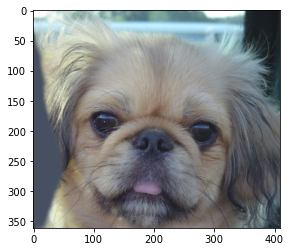

Visualization 1:


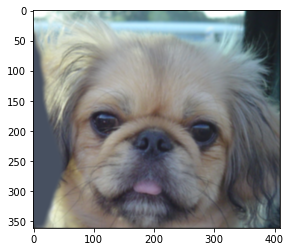

Visualization 2:


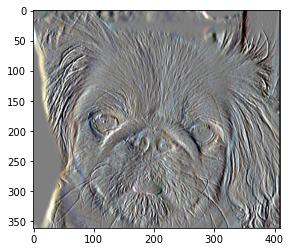

Visualization 3:


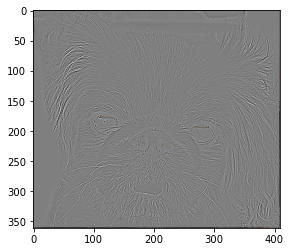

In [51]:
for idx in range(4):  # we are stacking 4 filters in the filter bank
    print('Visualization {}:'.format(idx))
    feature_map = feature_maps[0, [idx, idx+4, idx+8], :, :]
    # (c, h, w) --> (h, w, c) for matplotlib visualization purposes
    feature_map = np.transpose(feature_map.numpy(),(1,2,0))
    plt.figure()
    offset = 0 #offset for vis purposes. sobel and laplace use .5
    if idx > 1:
        offset = .5
    plt.imshow(np.clip(feature_map+offset,0,1))
    plt.show()
    save_image('../results/part3/visualization_{}.jpg'.format(idx), feature_map)

### Part 4: Frequency Compression and Image Filtering
Refer to the requirements in Part 4 and implement the necessary code on your own.

In [ ]:
raise NotImplementedError(
    "You need to finish the code by yourself."
)

使用项目根目录: e:\Codes\2025.2_CV\proj1\proj1_code
找到图像: e:\Codes\2025.2_CV\proj1\proj1_code\data\1a_dog.bmp
结果将保存至: e:\Codes\2025.2_CV\proj1\proj1_code\results\part4

处理图像使用不同保留比例...
保留比例	PSNR (dB)	估计压缩比
----------------------------------------
0.1		26.68		100.0:1
0.3		31.10		11.1:1
0.5		34.09		4.0:1
0.7		37.34		2.0:1

完成！压缩图像和频谱已保存到目录: e:\Codes\2025.2_CV\proj1\proj1_code\results\part4


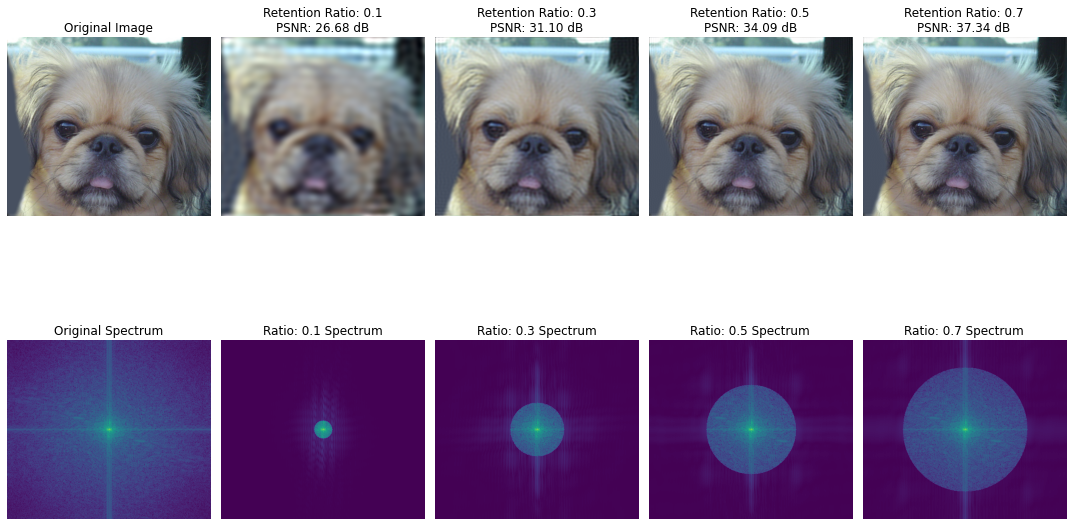

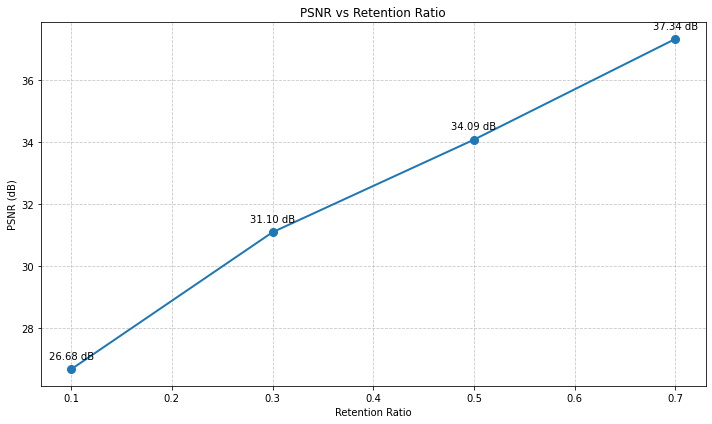


思考题：如何在降低保留比例的同时保持图像质量？
1. 使用自适应滤波 - 根据图像内容调整不同区域的保留比例
2. 在频域中使用非均匀采样 - 对低频部分进行更精细的保留
3. 结合小波变换 - 利用小波分解实现更高效的频率表示
4. 加入图像先验知识 - 考虑人类视觉系统对不同频率的敏感度
5. 使用感知质量度量而非PSNR来指导压缩


In [ ]:
#!/usr/bin/python3

from typing import Tuple

import numpy as np

import numpy.fft as fft

from proj1_code.utils import load_image, save_image, PIL_resize, numpy_arr_to_PIL_image, PIL_image_to_numpy_arr, im2single, single2im

# 导入可视化所需库
import matplotlib.pyplot as plt
from matplotlib import gridspec

def compute_psnr(original: np.ndarray, compressed: np.ndarray) -> float:
    """
    计算原始图像和压缩图像之间的峰值信噪比(PSNR)
    
    Args:
        original: 原始图像数组
        compressed: 压缩后的图像数组
    
    Returns:
        psnr: 峰值信噪比，单位为分贝(dB)
    """
    try:
        # 确保两个图像具有相同的形状
        if original.shape != compressed.shape:
            raise ValueError(f"图像形状不匹配: {original.shape} vs {compressed.shape}")
        
        # 将图像转换为相同类型
        original = original.astype(np.float64)
        compressed = compressed.astype(np.float64)
        
        # 确保图像在相同范围内进行比较
        if original.max() > 1.0:
            original = original / 255.0
        if compressed.max() > 1.0:
            compressed = compressed / 255.0
        
        # 计算均方误差(MSE)
        mse = np.mean(np.square(original - compressed))
        
        # 避免除以零
        if mse < 1e-10:
            return float('inf')
        
        # 计算峰值信噪比
        max_pixel = 1.0
        psnr = 10 * np.log10((max_pixel ** 2) / mse)
        
        return psnr
    
    except Exception as e:
        print(f"计算PSNR时出错: {e}")
        return 0.0

def compress_frequency(image: np.ndarray, retention_ratio: float) -> np.ndarray:
    """
    使用频率压缩方法压缩图像
    
    Args:
        image: 输入图像数组，形状为(H, W, C)或(H, W)
        retention_ratio: 保留的低频成分比例，取值范围[0, 1]
    
    Returns:
        compressed_image: 压缩后的图像数组，形状与输入相同
    """
    # 检查图像是否为彩色图像
    is_color = len(image.shape) == 3
    
    # 如果是彩色图像，分别处理每个通道
    if is_color:
        h, w, c = image.shape
        compressed_image = np.zeros_like(image)
        
        for i in range(c):
            compressed_image[:, :, i] = compress_single_channel(image[:, :, i], retention_ratio)
    else:
        # 灰度图像直接处理
        compressed_image = compress_single_channel(image, retention_ratio)
    
    return compressed_image

def compress_single_channel(channel: np.ndarray, retention_ratio: float) -> np.ndarray:
    """
    压缩单通道图像
    
    Args:
        channel: 单通道图像数组
        retention_ratio: 保留的低频成分比例
    
    Returns:
        compressed_channel: 压缩后的单通道图像
    """
    try:
        # 确保数据类型为float，以便进行傅里叶变换
        channel = channel.astype(np.float64)
        
        # 执行2D傅里叶变换
        f_transform = fft.fft2(channel)
        
        # 将零频率分量移到中心
        f_shift = fft.fftshift(f_transform)
        
        # 获取图像尺寸
        h, w = channel.shape
        center_h, center_w = h // 2, w // 2
        
        # 计算保留的半径
        radius = max(1, int(min(center_h, center_w) * retention_ratio))
        
        # 创建掩码，仅保留中心区域(低频部分)
        mask = np.zeros((h, w), dtype=np.float64)
        y, x = np.ogrid[:h, :w]
        mask_area = ((y - center_h) ** 2 + (x - center_w) ** 2) <= (radius ** 2)
        mask[mask_area] = 1
        
        # 应用掩码，保留低频成分
        f_shift_masked = f_shift * mask
        
        # 将零频率分量移回原位
        f_transform_masked = fft.ifftshift(f_shift_masked)
        
        # 执行逆傅里叶变换
        compressed_channel = np.real(fft.ifft2(f_transform_masked))
        
        # 确保结果在原始图像的值范围内
        if channel.max() > 1.0:
            compressed_channel = np.clip(compressed_channel, 0, 255)
        else:
            compressed_channel = np.clip(compressed_channel, 0, 1)
            
        return compressed_channel
        
    except Exception as e:
        print(f"压缩过程中出错: {e}")
        # 出错时返回原始通道
        return channel

def visualize_spectrum(image: np.ndarray, log_scale: bool = True) -> np.ndarray:
    """
    可视化图像的频谱
    
    Args:
        image: 输入图像
        log_scale: 是否使用对数尺度显示频谱
    
    Returns:
        spectrum: 可视化的频谱图像
    """
    # 如果是彩色图像，转换为灰度
    if len(image.shape) == 3:
        gray = np.mean(image, axis=2)
    else:
        gray = image
    
    # 执行傅里叶变换并将零频率移到中心
    f_transform = fft.fft2(gray)
    f_shift = fft.fftshift(f_transform)
    
    # 计算频谱幅度
    magnitude_spectrum = np.abs(f_shift)
    
    # 对数尺度显示（可选）
    if log_scale:
        # 添加一个小值避免log(0)
        magnitude_spectrum = np.log1p(magnitude_spectrum)
    
    # 归一化到[0, 1]范围便于显示
    spectrum = (magnitude_spectrum - magnitude_spectrum.min()) / (magnitude_spectrum.max() - magnitude_spectrum.min())
    
    return spectrum

def process_image_with_multiple_ratios(image_path: str, ratios: list) -> dict:
    """
    使用多个保留比例处理图像并计算PSNR
    
    Args:
        image_path: 图像文件路径
        ratios: 保留比例列表
    
    Returns:
        results: 包含压缩图像和PSNR的字典
    """
    # 加载图像
    original_image = load_image(image_path)
    
    results = {}
    for ratio in ratios:
        # 压缩图像
        compressed_image = compress_frequency(original_image, ratio)
        
        # 计算PSNR
        psnr = compute_psnr(original_image, compressed_image)
        
        # 存储结果
        results[ratio] = {
            'compressed_image': compressed_image,
            'psnr': psnr
        }
    
    return results

def visualize_comparison(original_image, compressed_results, results_dir=None):
    """
    可视化不同保留比例下的压缩结果并比较
    
    Args:
        original_image: 原始图像
        compressed_results: 包含不同保留比例下压缩图像和PSNR的字典
        results_dir: 结果保存目录，如果提供则保存图像
    """
    # 获取保留比例列表，按顺序排序
    ratios = sorted(compressed_results.keys())
    n_ratios = len(ratios)
    
    # 创建一个大图，包含原始图像和所有压缩图像
    plt.figure(figsize=(15, 10))
    
    # 创建网格布局
    gs = gridspec.GridSpec(2, n_ratios + 1)
    
    # 显示原始图像
    ax = plt.subplot(gs[0, 0])
    ax.imshow(original_image)
    ax.set_title('Original Image')
    ax.axis('off')
    
    # 显示不同保留比例下的压缩图像
    for i, ratio in enumerate(ratios):
        result = compressed_results[ratio]
        compressed_img = result['compressed_image']
        psnr = result['psnr']
        
        ax = plt.subplot(gs[0, i+1])
        ax.imshow(compressed_img)
        ax.set_title(f'Retention Ratio: {ratio:.1f}\nPSNR: {psnr:.2f} dB')
        ax.axis('off')
    
    # 显示原始图像的频谱
    ax = plt.subplot(gs[1, 0])
    original_spectrum = visualize_spectrum(original_image)
    ax.imshow(original_spectrum, cmap='viridis')
    ax.set_title('Original Spectrum')
    ax.axis('off')
    
    # 显示不同保留比例下的频谱
    for i, ratio in enumerate(ratios):
        result = compressed_results[ratio]
        compressed_img = result['compressed_image']
        
        ax = plt.subplot(gs[1, i+1])
        compressed_spectrum = visualize_spectrum(compressed_img)
        ax.imshow(compressed_spectrum, cmap='viridis')
        ax.set_title(f'Ratio: {ratio:.1f} Spectrum')
        ax.axis('off')
    
    plt.tight_layout()
    
    # 如果提供了保存目录，则保存图像
    if results_dir:
        import os
        plt.savefig(os.path.join(results_dir, 'comparison.png'), dpi=300, bbox_inches='tight')
    
    plt.show()

def visualize_psnr_plot(compressed_results):
    """
    绘制PSNR与保留比例的关系图
    
    Args:
        compressed_results: 包含不同保留比例下压缩图像和PSNR的字典
    """
    # 获取保留比例和对应的PSNR值
    ratios = []
    psnr_values = []
    
    for ratio in sorted(compressed_results.keys()):
        ratios.append(ratio)
        psnr_values.append(compressed_results[ratio]['psnr'])
    
    # 绘制PSNR-保留比例曲线
    plt.figure(figsize=(10, 6))
    plt.plot(ratios, psnr_values, 'o-', linewidth=2, markersize=8)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel('Retention Ratio')
    plt.ylabel('PSNR (dB)')
    plt.title('PSNR vs Retention Ratio')
    
    # 添加数据标签
    for i, (x, y) in enumerate(zip(ratios, psnr_values)):
        plt.annotate(f'{y:.2f} dB', 
                    (x, y), 
                    textcoords="offset points",
                    xytext=(0, 10), 
                    ha='center')
    
    plt.tight_layout()
    plt.show()

def calculate_compression_ratio(original_size, retention_ratio):
    """
    计算理论压缩比
    
    Args:
        original_size: 原始图像大小
        retention_ratio: 保留比例
    
    Returns:
        compression_ratio: 压缩比
    """
    # 估计保留低频成分所需的空间
    # 假设低频成分占用的空间与保留比例的平方成正比
    return 1 / (retention_ratio ** 2)

def main():
    """
    主函数：演示频率压缩算法的使用
    """
    # 设定保留比例
    retention_ratios = [0.1, 0.3, 0.5, 0.7]
    
    # 导入所需库
    import os
    import sys
    from pathlib import Path
    
    # 获取项目根目录
    try:
        # 尝试使用__file__变量(在正常Python脚本中有效)
        ROOT = Path(__file__).resolve().parent.parent  # ../..
    except NameError:
        # 在Jupyter Notebook中__file__未定义，使用替代方法
        try:
            # 假设当前工作目录是项目根目录或在其下级目录中
            current_dir = os.getcwd()
            if "proj1_code" in current_dir:
                # 如果在proj1_code目录中，向上一级
                ROOT = Path(current_dir).parent
            else:
                # 否则假设已经在项目根目录
                ROOT = Path(current_dir)
        except:
            # 最后的备选方案：直接指定路径
            print("警告：无法自动确定项目根目录，使用默认路径")
            ROOT = Path(".")
    
    print(f"使用项目根目录: {ROOT}")
    
    # 设置图像路径，尝试多个可能的位置
    possible_paths = [
        os.path.join(ROOT, "data", "1a_dog.bmp"),
        os.path.join(ROOT, "proj1_code", "data", "1a_dog.bmp"),
        os.path.join(".", "data", "1a_dog.bmp"),
        os.path.join("..", "data", "1a_dog.bmp")
    ]
    
    image_path = None
    for path in possible_paths:
        if os.path.exists(path):
            image_path = path
            print(f"找到图像: {path}")
            break
    
    if image_path is None:
        print("错误：找不到图像文件。请检查data目录是否存在且包含1a_dog.bmp")
        return
    
    # 加载图像
    original_image = load_image(image_path)
    
    # 为结果创建目录
    try:
        results_dir = os.path.join(ROOT, "results", "part4")
        os.makedirs(results_dir, exist_ok=True)
    except:
        results_dir = os.path.join(".", "results", "part4")
        os.makedirs(results_dir, exist_ok=True)
    
    print(f"结果将保存至: {results_dir}")
    
    # 保存原始图像
    save_image(os.path.join(results_dir, "original.jpg"), original_image)
    
    # 处理和保存频谱图
    spectrum = visualize_spectrum(original_image)
    save_image(os.path.join(results_dir, "spectrum.jpg"), spectrum)
    
    print("\n处理图像使用不同保留比例...")
    print("保留比例\tPSNR (dB)\t估计压缩比")
    print("-" * 40)
    
    # 存储不同保留比例的结果
    compressed_results = {}
    
    # 对每个保留比例进行处理
    for ratio in retention_ratios:
        # 压缩图像
        compressed_image = compress_frequency(original_image, ratio)
        
        # 计算PSNR
        psnr = compute_psnr(original_image, compressed_image)
        
        # 估计压缩比
        comp_ratio = calculate_compression_ratio(original_image.size, ratio)
        
        print(f"{ratio:.1f}\t\t{psnr:.2f}\t\t{comp_ratio:.1f}:1")
        
        # 保存压缩图像
        save_image(os.path.join(results_dir, f"compressed_{ratio:.1f}.jpg"), compressed_image)
        
        # 保存频谱图
        compressed_spectrum = visualize_spectrum(compressed_image)
        save_image(os.path.join(results_dir, f"spectrum_{ratio:.1f}.jpg"), compressed_spectrum)
        
        # 存储结果
        compressed_results[ratio] = {
            'compressed_image': compressed_image,
            'psnr': psnr
        }
    
    print("\n完成！压缩图像和频谱已保存到目录: " + results_dir)
    
    # 可视化比较不同保留比例的结果
    visualize_comparison(original_image, compressed_results, results_dir)
    
    # 绘制PSNR与保留比例的关系图
    visualize_psnr_plot(compressed_results)

if __name__ == "__main__":
    main()